Précision du modèle KNN : 95.00%

Classification Report:
               precision    recall  f1-score   support

Non Purchased       0.98      0.95      0.96        58
    Purchased       0.88      0.95      0.91        22

     accuracy                           0.95        80
    macro avg       0.93      0.95      0.94        80
 weighted avg       0.95      0.95      0.95        80



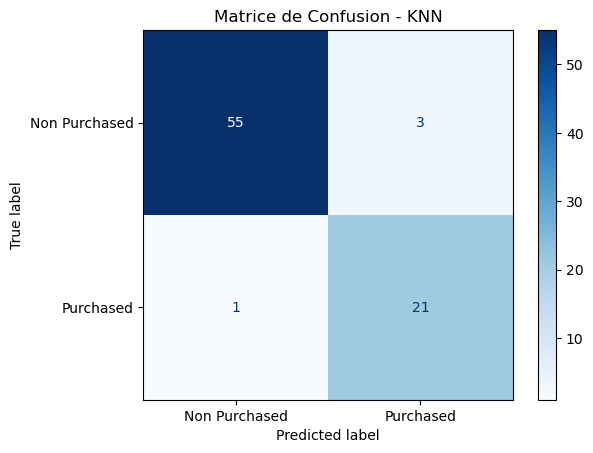

✅ Modèle et scaler sauvegardés avec succès!


In [ ]:
# IMPORTATIONS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
# 1. CHARGEMENT DU DATASET
data = pd.read_csv("Social_Network_Ads.csv")

# 2. PREPROCESSING - PAS D'ENCODAGE (que des nombres)
X = data[['Age', 'EstimatedSalary']].values  # Les 2 features
y = data['Purchased'].values                  # La cible

# 3. SPLIT TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 4. NORMALISATION
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. ENTRAINEMENT DU MODELE K-NN
knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
knn.fit(X_train, y_train)

# 6. PRÉDICTIONS
y_pred = knn.predict(X_test)

# 7. ÉVALUATION
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle KNN : {accuracy * 100:.2f}%")

class_names = ['Non Purchased', 'Purchased']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 8. MATRICE DE CONFUSION
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion - KNN")
plt.show()

joblib.dump(knn, "model_knn.pkl")

# Sauvegarder le scaler (StandardScaler)
joblib.dump(scaler, "scaler.pkl")

print("✅ Modèle et scaler sauvegardés avec succès!")
